In [1]:
# Step 1: Import libraries and load data

# Data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# Machine learning libraries (we will import more later)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ All libraries imported successfully!")

# Load your CSV file
df = pd.read_excel('Kano State Data (Rainfall as Average).xlsx')  

# Display basic info about the dataset
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)

# Check shape (rows, columns)
print(f"\n📊 Dataset shape: {df.shape}")
print(f"   - Rows: {df.shape[0]}")
print(f"   - Columns: {df.shape[1]}")

# Show first 5 rows
print("\n📋 First 5 rows of data:")
df.head()

✅ All libraries imported successfully!

DATASET OVERVIEW

📊 Dataset shape: (60, 6)
   - Rows: 60
   - Columns: 6

📋 First 5 rows of data:


,Year,Month,Under_5_Cases,Temperature,Rainfall,Relative humidity
0,2021,Jan,41210,22.524394,0.000000,21.778136
1,2021,Feb,37718,22.607085,0.007015,17.790295
2,2021,Mar,41695,28.045144,3.173074,16.977509
3,2021,Apr,43056,30.247063,6.142997,18.133066
4,2021,May,39604,31.517880,37.401289,32.888897


DATA EXPLORATION

📋 Data Types:
Year                   int64
Month                 object
Under_5_Cases          int64
Temperature          float64
Rainfall             float64
Relative humidity    float64
dtype: object

🔍 Missing Values:
Year                 0
Month                0
Under_5_Cases        0
Temperature          0
Rainfall             0
Relative humidity    0
dtype: int64

📊 Summary Statistics:
              Year  Under_5_Cases  Temperature    Rainfall  Relative humidity
count    60.000000      60.000000    60.000000   60.000000          60.000000
mean   2023.000000   68478.750000    26.431402   80.326574          42.681271
std       1.426148   21165.014715     3.223320  111.249287          22.921877
min    2021.000000   37342.000000    20.409723    0.000000          13.428940
25%    2022.000000   51057.000000    24.363490    0.166372          23.192534
50%    2023.000000   67218.000000    26.320855   13.970252          32.470525
75%    2024.000000   82545.000000    28.7

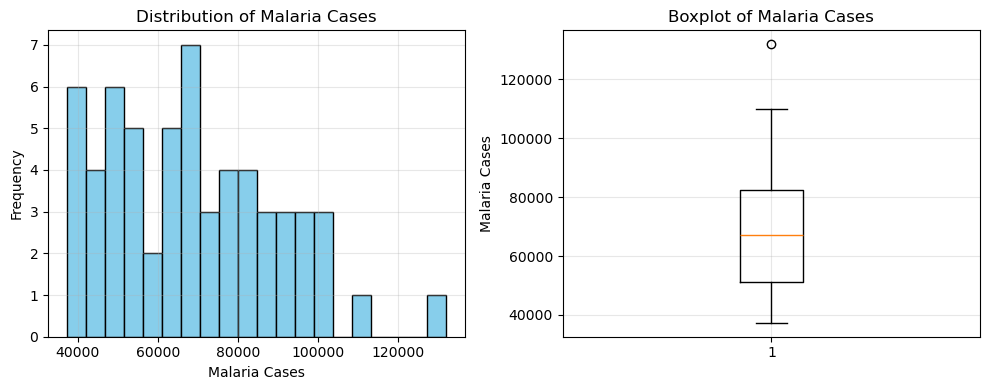

In [2]:
# Step 2: Data Exploration and Summary Statistics

print("="*60)
print("DATA EXPLORATION")
print("="*60)

# 1. Check data types
print("\n📋 Data Types:")
print(df.dtypes)

# 2. Check for missing values
print("\n🔍 Missing Values:")
missing_values = df.isnull().sum()
print(missing_values)

# If there are missing values, show percentage
if missing_values.sum() > 0:
    print("\nPercentage of missing values:")
    print((missing_values / len(df)) * 100)

# 3. Summary statistics
print("\n📊 Summary Statistics:")
print(df.describe())

# 4. Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\n🔁 Duplicate rows: {duplicates}")

# 5. Check unique values in categorical columns
print("\n🏷️ Unique Values in Categorical Columns:")

# Check Year column
print(f"Years in dataset: {sorted(df['Year'].unique())}")

# Check Month column
print(f"Months in dataset: {df['Month'].unique()}")

# Check if all 12 months are present
expected_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
present_months = sorted(df['Month'].unique())
print(f"\nAll months present? {set(expected_months) == set(present_months)}")
if set(expected_months) != set(present_months):
    print(f"Missing months: {set(expected_months) - set(present_months)}")

# 6. Range check for key variables
print("\n🎯 Range Check for Key Variables:")
print(f"Malaria Cases (Under_5_Cases):")
print(f"  - Min: {df['Under_5_Cases'].min():.0f}")
print(f"  - Max: {df['Under_5_Cases'].max():.0f}")
print(f"  - Mean: {df['Under_5_Cases'].mean():.1f}")

print(f"\nRainfall:")
print(f"  - Min: {df['Rainfall'].min():.1f}")
print(f"  - Max: {df['Rainfall'].max():.1f}")
print(f"  - Mean: {df['Rainfall'].mean():.1f}")

print(f"\nTemperature:")
print(f"  - Min: {df['Temperature'].min():.1f}")
print(f"  - Max: {df['Temperature'].max():.1f}")
print(f"  - Mean: {df['Temperature'].mean():.1f}")

print(f"\nRelative Humidity:")
print(f"  - Min: {df['Relative humidity'].min():.1f}")
print(f"  - Max: {df['Relative humidity'].max():.1f}")
print(f"  - Mean: {df['Relative humidity'].mean():.1f}")

# 7. Quick visual check - distribution of malaria cases
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['Under_5_Cases'], bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Malaria Cases')
plt.ylabel('Frequency')
plt.title('Distribution of Malaria Cases')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['Under_5_Cases'])
plt.ylabel('Malaria Cases')
plt.title('Boxplot of Malaria Cases')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

✅ Date column created and data sorted chronologically!

📅 Date range: 2021-01-01 00:00:00 to 2025-12-01 00:00:00
📊 Total months: 60

📋 First 5 rows (sorted by date):

TIME SERIES VISUALIZATION


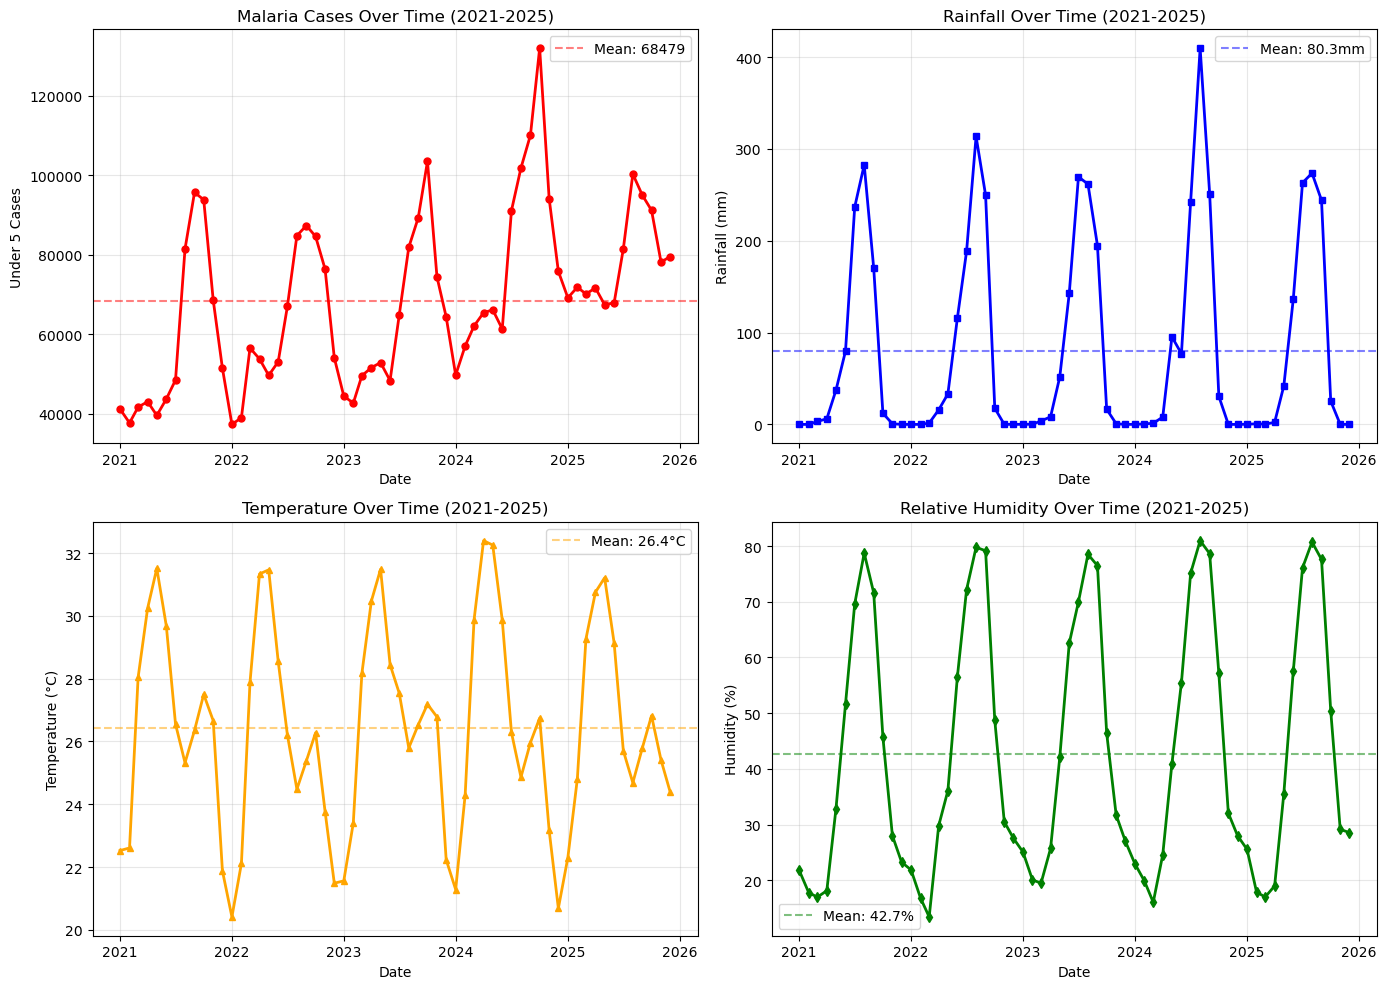


SEASONAL PATTERN ANALYSIS

📊 Monthly Averages (across all years):
       Under_5_Cases  Rainfall  Temperature  Relative humidity
Month                                                         
Jan          48390.6       0.1         21.6               23.4
Feb          49669.8       0.3         23.4               18.5
Mar          56012.0       2.0         28.6               16.6
Apr          57110.2       8.1         31.0               23.4
May          55148.4      51.9         31.6               37.5
Jun          54886.6     110.5         29.1               56.8
Jul          70599.6     240.1         26.5               72.6
Aug          90041.2     308.2         25.0               79.8
Sep          95481.6     222.0         26.0               76.7
Oct         101005.2      20.5         26.9               49.7
Nov          78331.2       0.3         25.2               30.3
Dec          65068.6       0.0         22.1               26.9


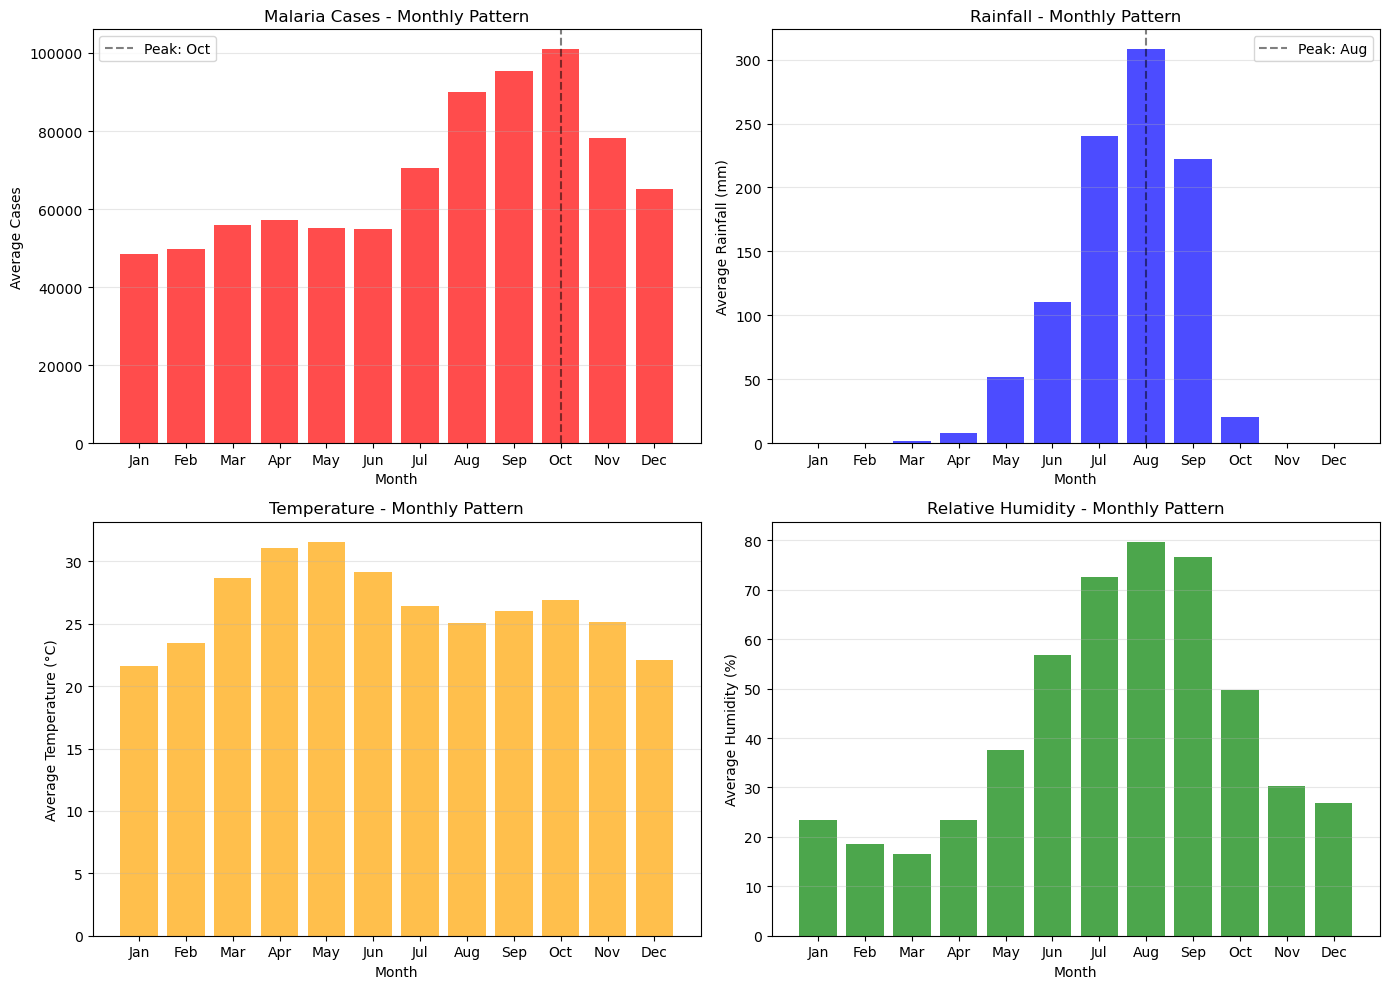


KEY OBSERVATIONS

1️⃣ Peak malaria month: Oct (101005 cases on average)
2️⃣ Peak rainfall month: Aug (308.2 mm on average)
3️⃣ Malaria peak occurs 2 month(s) after rainfall peak

4️⃣ Yearly average malaria cases:
   2021: 57212 cases
   2022: 61977 cases
      (Change from previous year: +8.3%)
   2023: 64000 cases
      (Change from previous year: +3.3%)
   2024: 80557 cases
      (Change from previous year: +25.9%)
   2025: 78647 cases
      (Change from previous year: -2.4%)

✅ Step 3 complete! Analyze the patterns above before moving to Step 4.


In [3]:
# Step 3: Create Date Column and Visualize Patterns Over Time

# Create a proper date column
# This combines Year and Month into a single date (first day of each month)
month_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# First, create a month number column temporarily
df['month_num'] = df['Month'].map(month_to_num)

# Create date column (using first day of the month)
df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['month_num'].astype(str) + '-01')

# Sort by date (very important for time series)
df = df.sort_values('date').reset_index(drop=True)

print("✅ Date column created and data sorted chronologically!")
print(f"\n📅 Date range: {df['date'].min()} to {df['date'].max()}")
print(f"📊 Total months: {len(df)}")

# Show the first few rows with the new date column
print("\n📋 First 5 rows (sorted by date):")
df[['date', 'Year', 'Month', 'Under_5_Cases', 'Rainfall', 'Temperature']].head()

# ============================================================================
# VISUALIZATION: Time Series Plots
# ============================================================================

print("\n" + "="*60)
print("TIME SERIES VISUALIZATION")
print("="*60)

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Malaria cases over time
axes[0, 0].plot(df['date'], df['Under_5_Cases'], marker='o', linestyle='-', 
                 color='red', linewidth=2, markersize=5)
axes[0, 0].set_title('Malaria Cases Over Time (2021-2025)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Under 5 Cases')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=df['Under_5_Cases'].mean(), color='red', linestyle='--', 
                   alpha=0.5, label=f"Mean: {df['Under_5_Cases'].mean():.0f}")
axes[0, 0].legend()

# 2. Rainfall over time
axes[0, 1].plot(df['date'], df['Rainfall'], marker='s', linestyle='-', 
                 color='blue', linewidth=2, markersize=5)
axes[0, 1].set_title('Rainfall Over Time (2021-2025)')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Rainfall (mm)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=df['Rainfall'].mean(), color='blue', linestyle='--', 
                   alpha=0.5, label=f"Mean: {df['Rainfall'].mean():.1f}mm")
axes[0, 1].legend()

# 3. Temperature over time
axes[1, 0].plot(df['date'], df['Temperature'], marker='^', linestyle='-', 
                 color='orange', linewidth=2, markersize=5)
axes[1, 0].set_title('Temperature Over Time (2021-2025)')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Temperature (°C)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=df['Temperature'].mean(), color='orange', linestyle='--', 
                   alpha=0.5, label=f"Mean: {df['Temperature'].mean():.1f}°C")
axes[1, 0].legend()

# 4. Relative humidity over time
axes[1, 1].plot(df['date'], df['Relative humidity'], marker='d', linestyle='-', 
                 color='green', linewidth=2, markersize=5)
axes[1, 1].set_title('Relative Humidity Over Time (2021-2025)')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Humidity (%)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=df['Relative humidity'].mean(), color='green', linestyle='--', 
                   alpha=0.5, label=f"Mean: {df['Relative humidity'].mean():.1f}%")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ============================================================================
# SEASONAL PATTERN ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("SEASONAL PATTERN ANALYSIS")
print("="*60)

# Group by month and calculate averages across all years
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_avg = df.groupby('Month').agg({
    'Under_5_Cases': 'mean',
    'Rainfall': 'mean',
    'Temperature': 'mean',
    'Relative humidity': 'mean'
}).reindex(month_order)

print("\n📊 Monthly Averages (across all years):")
print(monthly_avg.round(1))

# Visualize seasonal patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Malaria seasonality
axes[0, 0].bar(monthly_avg.index, monthly_avg['Under_5_Cases'], color='red', alpha=0.7)
axes[0, 0].set_title('Malaria Cases - Monthly Pattern')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Average Cases')
axes[0, 0].grid(True, alpha=0.3, axis='y')
# Highlight peak months
max_month = monthly_avg['Under_5_Cases'].idxmax()
axes[0, 0].axvline(x=month_order.index(max_month), color='black', linestyle='--', 
                   alpha=0.5, label=f'Peak: {max_month}')
axes[0, 0].legend()

# Rainfall seasonality
axes[0, 1].bar(monthly_avg.index, monthly_avg['Rainfall'], color='blue', alpha=0.7)
axes[0, 1].set_title('Rainfall - Monthly Pattern')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Rainfall (mm)')
axes[0, 1].grid(True, alpha=0.3, axis='y')
max_rain_month = monthly_avg['Rainfall'].idxmax()
axes[0, 1].axvline(x=month_order.index(max_rain_month), color='black', linestyle='--', 
                   alpha=0.5, label=f'Peak: {max_rain_month}')
axes[0, 1].legend()

# Temperature seasonality
axes[1, 0].bar(monthly_avg.index, monthly_avg['Temperature'], color='orange', alpha=0.7)
axes[1, 0].set_title('Temperature - Monthly Pattern')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average Temperature (°C)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Humidity seasonality
axes[1, 1].bar(monthly_avg.index, monthly_avg['Relative humidity'], color='green', alpha=0.7)
axes[1, 1].set_title('Relative Humidity - Monthly Pattern')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Humidity (%)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================================
# OBSERVATIONS
# ============================================================================

print("\n" + "="*60)
print("KEY OBSERVATIONS")
print("="*60)

# 1. Find the peak malaria month
peak_malaria_month = monthly_avg['Under_5_Cases'].idxmax()
peak_malaria_value = monthly_avg.loc[peak_malaria_month, 'Under_5_Cases']
print(f"\n1️⃣ Peak malaria month: {peak_malaria_month} ({peak_malaria_value:.0f} cases on average)")

# 2. Find the peak rainfall month
peak_rain_month = monthly_avg['Rainfall'].idxmax()
peak_rain_value = monthly_avg.loc[peak_rain_month, 'Rainfall']
print(f"2️⃣ Peak rainfall month: {peak_rain_month} ({peak_rain_value:.1f} mm on average)")

# 3. Check relationship: Does malaria peak after rainfall peak?
# Find the month after peak rainfall
rain_idx = month_order.index(peak_rain_month)
malaria_peak_idx = month_order.index(peak_malaria_month)
lag_months = (malaria_peak_idx - rain_idx) % 12
print(f"3️⃣ Malaria peak occurs {lag_months} month(s) after rainfall peak")

# 4. Yearly trends
yearly_avg = df.groupby('Year')['Under_5_Cases'].mean()
print(f"\n4️⃣ Yearly average malaria cases:")
for year, cases in yearly_avg.items():
    print(f"   {year}: {cases:.0f} cases")
    if year > 2021:
        prev_year = yearly_avg[year-1]
        change = ((cases - prev_year) / prev_year) * 100
        print(f"      (Change from previous year: {change:+.1f}%)")

print("\n✅ Step 3 complete! Analyze the patterns above before moving to Step 4.")

CORRELATION ANALYSIS

📊 Correlation Matrix:
                   Under_5_Cases  Temperature  Rainfall  Relative humidity
Under_5_Cases              1.000       -0.048     0.438              0.586
Temperature               -0.048        1.000     0.018              0.056
Rainfall                   0.438        0.018     1.000              0.920
Relative humidity          0.586        0.056     0.920              1.000


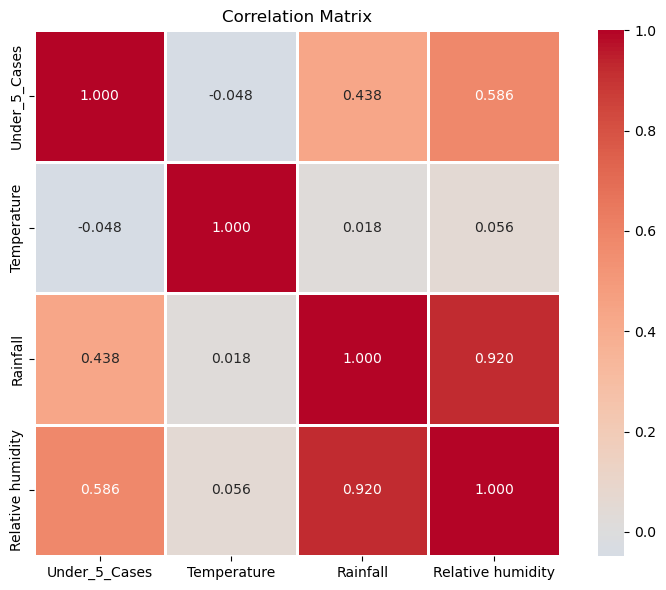


📊 Correlations with Malaria Cases:
  Temperature: -0.048
  Rainfall: 0.438
  Relative humidity: 0.586


In [4]:
# Step 4: Correlation Analysis

print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Select numeric columns
numeric_cols = ['Under_5_Cases', 'Temperature', 'Rainfall', 'Relative humidity']

# Calculate correlations
correlation_matrix = df[numeric_cols].corr()

print("\n📊 Correlation Matrix:")
print(correlation_matrix.round(3))

# Visualize heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            linewidths=2, fmt='.3f', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Show correlations with malaria
print("\n📊 Correlations with Malaria Cases:")
for col in numeric_cols:
    if col != 'Under_5_Cases':
        corr = df['Under_5_Cases'].corr(df[col])
        print(f"  {col}: {corr:.3f}")

In [5]:
# Step 5: Convert Month Names to Numbers

print("="*60)
print("MONTH LABEL ENCODING")
print("="*60)

# Create month to number mapping
month_to_num = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Add month number column
df['month_number'] = df['Month'].map(month_to_num)

print("\n✅ Month number column added!")

# Show the mapping
print("\n📋 Month mapping:")
print(df[['Month', 'month_number']].drop_duplicates().sort_values('month_number'))

# Quick check for any unmapped months
if df['month_number'].isnull().sum() == 0:
    print("\n✅ All months mapped successfully!")
else:
    print(f"\n⚠️ Warning: {df['month_number'].isnull().sum()} months failed to map!")

print("\n✅ Step 5 complete!")

MONTH LABEL ENCODING

✅ Month number column added!

📋 Month mapping:
   Month  month_number
0    Jan             1
1    Feb             2
2    Mar             3
3    Apr             4
4    May             5
5    Jun             6
6    Jul             7
7    Aug             8
8    Sep             9
9    Oct            10
10   Nov            11
11   Dec            12

✅ All months mapped successfully!

✅ Step 5 complete!


### Using Cyclic Encoding

CYCLICAL ENCODING OF MONTHS
✅ Cyclical features added!

📋 Month encoding (sin/cos):
   Month  month_number  month_number_sin  month_number_cos
0    Jan             1      5.000000e-01      8.660254e-01
1    Feb             2      8.660254e-01      5.000000e-01
2    Mar             3      1.000000e+00      6.123234e-17
3    Apr             4      8.660254e-01     -5.000000e-01
4    May             5      5.000000e-01     -8.660254e-01
5    Jun             6      1.224647e-16     -1.000000e+00
6    Jul             7     -5.000000e-01     -8.660254e-01
7    Aug             8     -8.660254e-01     -5.000000e-01
8    Sep             9     -1.000000e+00     -1.836970e-16
9    Oct            10     -8.660254e-01      5.000000e-01
10   Nov            11     -5.000000e-01      8.660254e-01
11   Dec            12     -2.449294e-16      1.000000e+00

🔍 Checking December vs January:
December: sin=-0.000, cos=1.000
January:  sin=0.500, cos=0.866


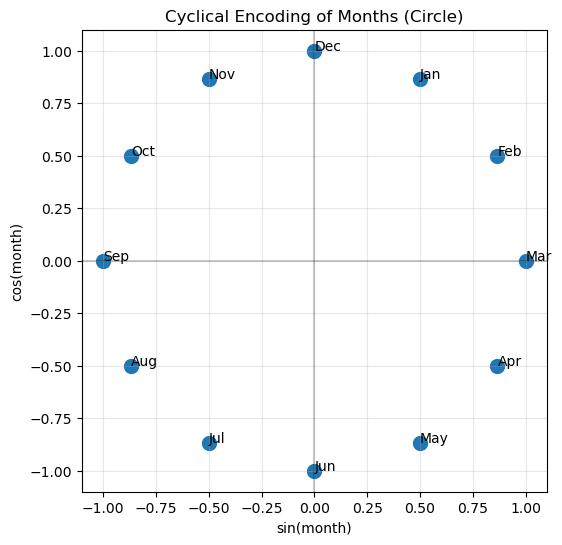


✅ Step 6 complete!


In [6]:
# Step 6: Create Cyclical Features for Months

print("="*60)
print("CYCLICAL ENCODING OF MONTHS")
print("="*60)

# Function to create cyclical features
def add_cyclical_features(df, column, max_value):
    df[f'{column}_sin'] = np.sin(2 * np.pi * df[column] / max_value)
    df[f'{column}_cos'] = np.cos(2 * np.pi * df[column] / max_value)
    return df

# Apply cyclical encoding to month_number (12 months)
df = add_cyclical_features(df, 'month_number', 12)

print("✅ Cyclical features added!")

# Show the results
print("\n📋 Month encoding (sin/cos):")
print(df[['Month', 'month_number', 'month_number_sin', 'month_number_cos']].drop_duplicates().sort_values('month_number'))

# Verify: December and January are close
print("\n🔍 Checking December vs January:")
dec_sin = df[df['Month'] == 'Dec']['month_number_sin'].values[0]
dec_cos = df[df['Month'] == 'Dec']['month_number_cos'].values[0]
jan_sin = df[df['Month'] == 'Jan']['month_number_sin'].values[0]
jan_cos = df[df['Month'] == 'Jan']['month_number_cos'].values[0]

print(f"December: sin={dec_sin:.3f}, cos={dec_cos:.3f}")
print(f"January:  sin={jan_sin:.3f}, cos={jan_cos:.3f}")

# Visualize the circle
plt.figure(figsize=(6, 6))
months = df[['Month', 'month_number_sin', 'month_number_cos']].drop_duplicates()
plt.scatter(months['month_number_sin'], months['month_number_cos'], s=100)
for i, row in months.iterrows():
    plt.annotate(row['Month'], (row['month_number_sin'], row['month_number_cos']))
plt.xlabel('sin(month)')
plt.ylabel('cos(month)')
plt.title('Cyclical Encoding of Months (Circle)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.2)
plt.show()

print("\n✅ Step 6 complete!")

In [10]:
# Step 9: Train All Models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*60)
print("TRAINING ALL MODELS")
print("="*60)

# Prepare features (exclude Year column)
feature_cols = ['month_number_sin', 'month_number_cos', 'Temperature', 'Rainfall', 'Relative humidity']
X = df[feature_cols]
y = df['Under_5_Cases']

print(f"📊 Features: {len(feature_cols)} columns")
print(f"📊 Samples: {len(X)} rows")

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Train set: {len(X_train)} rows")
print(f"✅ Test set: {len(X_test)} rows")

# Scale features (for SVR and Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

# Store results
results = {}

print("\n" + "="*60)
print("TRAINING MODELS...")
print("="*60)

# Train each model
for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    
    # Use scaled data for Linear Regression and SVR
    if name in ['Linear Regression', 'SVR']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'predictions': y_pred
    }
    
    print(f"  ✅ R²: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Create comparison table
comparison_cyclical = pd.DataFrame({
    name: {
        'MAE': results[name]['MAE'],
        'RMSE': results[name]['RMSE'],
        'R²': results[name]['R²']
    }
    for name in results.keys()
}).T

print(comparison_cyclical.round(4))

# Find best model
best_model = comparison_cyclical['R²'].idxmax()
print(f"\n🏆 Best Model: {best_model}")
print(f"   R² Score: {comparison_cyclical.loc[best_model, 'R²']:.4f}")

print("\n✅ Step 9 complete!")

TRAINING ALL MODELS
📊 Features: 5 columns
📊 Samples: 60 rows

✅ Train set: 48 rows
✅ Test set: 12 rows

TRAINING MODELS...

🚀 Training Linear Regression...
  ✅ R²: 0.6074, RMSE: 18142.12, MAE: 14599.12

🚀 Training Decision Tree...
  ✅ R²: 0.4921, RMSE: 20636.88, MAE: 15988.25

🚀 Training Random Forest...
  ✅ R²: 0.5881, RMSE: 18584.13, MAE: 14559.22

🚀 Training XGBoost...
  ✅ R²: 0.6332, RMSE: 17536.56, MAE: 13572.25

🚀 Training SVR...
  ✅ R²: -0.0235, RMSE: 29294.33, MAE: 24769.42

MODEL COMPARISON
                          MAE        RMSE      R²
Linear Regression  14599.1239  18142.1216  0.6074
Decision Tree      15988.2500  20636.8798  0.4921
Random Forest      14559.2192  18584.1291  0.5881
XGBoost            13572.2529  17536.5611  0.6332
SVR                24769.4181  29294.3306 -0.0235

🏆 Best Model: XGBoost
   R² Score: 0.6332

✅ Step 9 complete!


### Using Label Encoding

In [11]:
# Step 9: Train All Models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*60)
print("TRAINING ALL MODELS")
print("="*60)

# Prepare features (exclude Year column)
feature_cols = ['month_number', 'Temperature', 'Rainfall', 'Relative humidity']
X = df[feature_cols]
y = df['Under_5_Cases']

print(f"📊 Features: {len(feature_cols)} columns")
print(f"📊 Samples: {len(X)} rows")

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Train set: {len(X_train)} rows")
print(f"✅ Test set: {len(X_test)} rows")

# Scale features (for SVR and Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

# Store results
results = {}

print("\n" + "="*60)
print("TRAINING MODELS...")
print("="*60)

# Train each model
for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    
    # Use scaled data for Linear Regression and SVR
    if name in ['Linear Regression', 'SVR']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'predictions': y_pred
    }
    
    print(f"  ✅ R²: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Create comparison table
comparison_label = pd.DataFrame({
    name: {
        'MAE': results[name]['MAE'],
        'RMSE': results[name]['RMSE'],
        'R²': results[name]['R²']
    }
    for name in results.keys()
}).T

print(comparison_label.round(4))

# Find best model
best_model = comparison_label['R²'].idxmax()
print(f"\n🏆 Best Model: {best_model}")
print(f"   R² Score: {comparison_label.loc[best_model, 'R²']:.4f}")

print("\n✅ Step 9 complete!")

TRAINING ALL MODELS
📊 Features: 4 columns
📊 Samples: 60 rows

✅ Train set: 48 rows
✅ Test set: 12 rows

TRAINING MODELS...

🚀 Training Linear Regression...
  ✅ R²: 0.3518, RMSE: 23311.99, MAE: 18125.64

🚀 Training Decision Tree...
  ✅ R²: 0.6055, RMSE: 18187.57, MAE: 13445.25

🚀 Training Random Forest...
  ✅ R²: 0.5545, RMSE: 19325.87, MAE: 14459.83

🚀 Training XGBoost...
  ✅ R²: 0.5901, RMSE: 18539.28, MAE: 13046.18

🚀 Training SVR...
  ✅ R²: -0.0235, RMSE: 29294.50, MAE: 24769.54

MODEL COMPARISON
                          MAE        RMSE      R²
Linear Regression  18125.6405  23311.9906  0.3518
Decision Tree      13445.2500  18187.5684  0.6055
Random Forest      14459.8275  19325.8743  0.5545
XGBoost            13046.1797  18539.2824  0.5901
SVR                24769.5438  29294.5000 -0.0235

🏆 Best Model: Decision Tree
   R² Score: 0.6055

✅ Step 9 complete!


### Using One-Hot Encoding

In [12]:
# Step 10: Train Models with One-Hot Encoding

print("="*60)
print("TRAINING MODELS WITH ONE-HOT ENCODING")
print("="*60)

# Create one-hot encoding for months
month_dummies = pd.get_dummies(df['Month'], prefix='month', drop_first=True)

# Prepare features (exclude Year, Month, and cyclical features)
feature_cols = ['Temperature', 'Rainfall', 'Relative humidity']
X_onehot = pd.concat([df[feature_cols], month_dummies], axis=1)
y = df['Under_5_Cases']

print(f"📊 Features: {X_onehot.shape[1]} columns (including {month_dummies.shape[1]} month dummies)")
print(f"📊 Samples: {len(X_onehot)} rows")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_onehot, y, test_size=0.2, random_state=42)

# Scale features (for SVR and Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

# Store results
results_onehot = {}

print("\n" + "="*60)
print("TRAINING MODELS WITH ONE-HOT ENCODING...")
print("="*60)

# Train each model
for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    
    if name in ['Linear Regression', 'SVR']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results_onehot[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    }
    
    print(f"  ✅ R²: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")

print("\n" + "="*60)
print("RESULTS: ONE-HOT ENCODING")
print("="*60)

comparison_onehot = pd.DataFrame({
    name: {
        'MAE': results_onehot[name]['MAE'],
        'RMSE': results_onehot[name]['RMSE'],
        'R²': results_onehot[name]['R²']
    }
    for name in results_onehot.keys()
}).T

print(comparison_onehot.round(4))

best_onehot = comparison_onehot['R²'].idxmax()
print(f"\n🏆 Best Model (One-Hot): {best_onehot}")
print(f"   R² Score: {comparison_onehot.loc[best_onehot, 'R²']:.4f}")

# ============================================================================


TRAINING MODELS WITH ONE-HOT ENCODING
📊 Features: 14 columns (including 11 month dummies)
📊 Samples: 60 rows

TRAINING MODELS WITH ONE-HOT ENCODING...

🚀 Training Linear Regression...
  ✅ R²: 0.6622, RMSE: 16829.67, MAE: 13132.00

🚀 Training Decision Tree...
  ✅ R²: 0.5901, RMSE: 18538.82, MAE: 13956.58

🚀 Training Random Forest...
  ✅ R²: 0.4510, RMSE: 21455.56, MAE: 17100.92

🚀 Training XGBoost...
  ✅ R²: 0.6554, RMSE: 16998.11, MAE: 13645.64

🚀 Training SVR...
  ✅ R²: -0.0237, RMSE: 29296.19, MAE: 24770.87

RESULTS: ONE-HOT ENCODING
                          MAE        RMSE      R²
Linear Regression  13131.9967  16829.6687  0.6622
Decision Tree      13956.5833  18538.8161  0.5901
Random Forest      17100.9208  21455.5561  0.4510
XGBoost            13645.6416  16998.1110  0.6554
SVR                24770.8668  29296.1866 -0.0237

🏆 Best Model (One-Hot): Linear Regression
   R² Score: 0.6622
